In [2]:
#import relevant libraries: pip install re, pip install natsort, pip install plotly==5.10.0
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'Inter'
import dabest

#NOTE: SUPPRESSES WARNINGS!

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)

print(dabest.__version__)
print(np.version.version)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 49.36it/s]

Numba compilation complete!
2025.03.27
2.1.3


In [3]:
#Initial file processing
computer1 = "C:\\Users\\User"
computer2 = "C:\\Users\\lnico"
homecomp = "D:"
filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data\\Fecundity\\"
specifiedpath = computer1
openPath = specifiedpath + filedir

files = os.listdir(openPath)
filename = openPath + "Compiled.csv"
#filenameATR = openPath + "20250923-20251008 NL fecundity.csv"

dfe=pd.read_csv(filename)

In [4]:
inter_font_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Regular.ttf"
inter_bold_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Bold.ttf"
inter_italic_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Italic.ttf"

# Register fonts
import matplotlib.font_manager as fm
fm.fontManager.addfont(inter_font_path)
fm.fontManager.addfont(inter_bold_path)
fm.fontManager.addfont(inter_italic_path)

# Set Inter as default font
plt.rcParams['font.family'] = 'Inter'

In [5]:
df = pd.concat([dfe['Genotype'], dfe['Taken for expt'], dfe['Pupated'] , dfe['Eclosed']], axis = 1)

if df['Genotype'].str.contains("eOPN3").any():
   df['Genotype'] = df['Genotype'].str.replace("eOPN3", "AsOPN3")

if df['Genotype'].str.contains(" ACR").any():
   df['Genotype'] = df['Genotype'].str.replace(" ACR", " GtACR1")
   
if df['Genotype'].str.contains("[ATR]").any():
   df['Genotype'] = df['Genotype'].str.replace(" [ATR]", "*")

df['number'] = pd.factorize(df.Genotype)[0].tolist()

repeats = int(df[df.number == 1].number.value_counts().values[0])

In [6]:
dftotal = pd.DataFrame()
dfnumbers = pd.DataFrame()
for n in df['Genotype'].unique():
    df1 = pd.DataFrame()
    df2 = pd.DataFrame()
    embryos = int(df[df['Genotype'] == n]['Taken for expt'].sum())
    pupated = int(df[df['Genotype'] == n]['Pupated'].sum())
    eclosed = int(df[df['Genotype'] == n]['Eclosed'].sum())
    
    #total embryos
    df1[n+" (EM)"] = [1]*embryos
    df2[n+"_embryos"] = [embryos]
    
    #total pupate
    failpupate =embryos-pupated                        
    df1[n + " (LE)"] = [0]*failpupate + [1]*pupated
    df2[n + "_pupate"] = [pupated]
    
    #total eclosed
    df1[n + " (PE)"] = [0]*failpupate + [0]*(pupated-eclosed) + [1]*eclosed 
    df2[n + "_eclose"] = [eclosed]
    
    df1['ID'] = range(1, len(df1)+1)
    # dftotal = pd.concat([dftotal,df1], axis =1).reset_index(drop = True)
    dfnumbers = pd.concat([dfnumbers,df2], axis =1).reset_index(drop = True)
    
    dfmelted = pd.melt(df1, id_vars = ["ID"], value_vars=df1.columns[:-1])

    dftotal = pd.concat([dfmelted, dftotal], axis = 0).reset_index(drop = True)
    

dftotal['lethality'] = dftotal['value'] = 1 - dftotal['value']

print(dftotal)

     ID             variable  value  lethality
0     1  elav x GtACR1* (EM)      0          0
1     2  elav x GtACR1* (EM)      0          0
2     3  elav x GtACR1* (EM)      0          0
3     4  elav x GtACR1* (EM)      0          0
4     5  elav x GtACR1* (EM)      0          0
..   ..                  ...    ...        ...
721  68    w1118 x elav (PE)      0          0
722  69    w1118 x elav (PE)      0          0
723  70    w1118 x elav (PE)      0          0
724  71    w1118 x elav (PE)      0          0
725  72    w1118 x elav (PE)      0          0

[726 rows x 4 columns]


<Figure size 800x600 with 0 Axes>

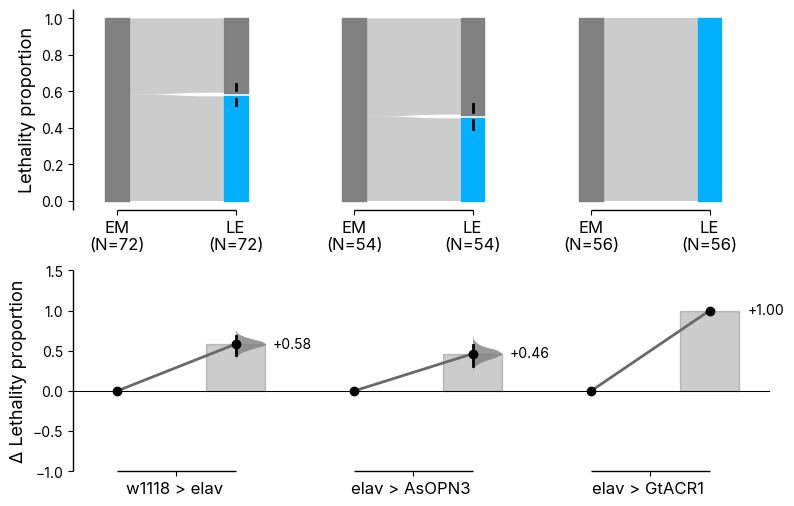

In [ ]:
multi_groups_baseline = dabest.load(dftotal, idx=(("w1118 x elav (EM)", 'w1118 x elav (PE)' )
                                                  ,("elav x AsOPN3 (EM)", 'elav x AsOPN3 (PE)')
                                                  ,("elav x GtACR1 (EM)", 'elav x GtACR1 (PE)')), x = "variable", y = "lethality",
                                        proportional=True, paired="baseline", id_col="ID")
fig = plt.figure(figsize=(8, 6))

color_wt = "#000000"
color_trans = "#00AEFF"  
color_gray = "#808080"

common_style = {'fontsize_rawxlabel': 9, 'fontsize_rawylabel': 13, 'fontsize_contrastxlabel': 9,
                'fontsize_contrastylabel': 13, 'fontsize_delta2label': 12, 'contrast_marker_size': 6}

ax = multi_groups_baseline.mean_diff.plot(custom_palette={0: "#808080", 1: color_trans}, 
    contrast_ylim = (-1, 1.5), **common_style);

ax.axes[0].set_ylabel('Lethality proportion')
ax.axes[1].set_ylabel('Δ Lethality proportion')

results = multi_groups_baseline.mean_diff.results


#sample sizes
n1 = results.loc[0, 'control_N']  
n2 = results.loc[1, 'control_N']  
n3 = results.loc[2, 'control_N']  

gen1 = results.loc[0,"control"].split("(")[0].replace("x", ">")
gen2 = results.loc[1,"control"].split("(")[0].replace("x", ">")
gen3 = results.loc[2,"control"].split("(")[0].replace("x", ">")

ax.axes[1].spines['bottom'].set_visible(False)
ax.axes[1].set_xticks([0.5, 2.5, 4.5])
ax.axes[0].set_xticklabels([ f"EM\n(N={n1})", 
                            f"LE\n(N={n1})", 
                            
                            f"EM\n(N={n2})",
                            f"LE\n(N={n2})" ,
                            
                            f"EM\n(N={n3})",
                            f"LE\n(N={n3})" ], fontsize=12)
ax.axes[1].set_xticklabels([gen1, gen2, gen3], fontsize=12)


mpl.rcParams['svg.fonttype'] = 'none' 
plt.show()
#ax.savefig(openPath + "Fecundity_EMLE_lethality.svg", bbox_inches = 'tight')

<Figure size 800x600 with 0 Axes>

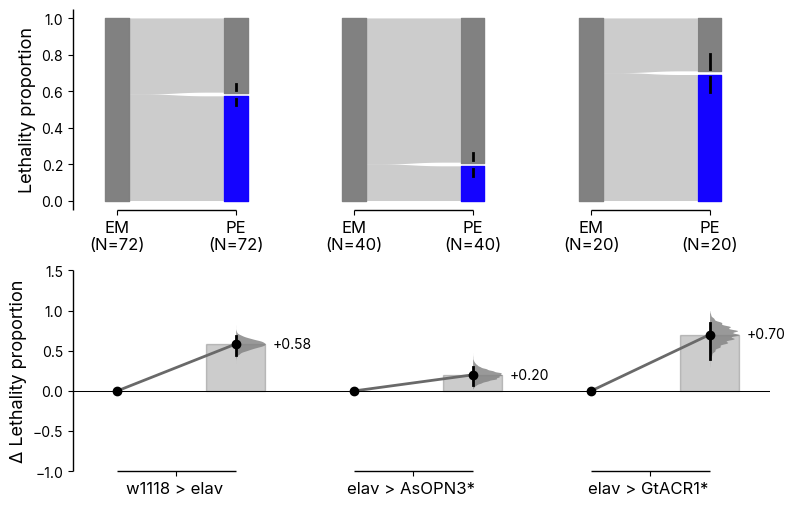

In [11]:
multi_groups_baseline = dabest.load(dftotal, idx=(("w1118 x elav (EM)", 'w1118 x elav (PE)' )
                                                  ,("elav x AsOPN3* (EM)", 'elav x AsOPN3* (PE)')
                                                  ,("elav x GtACR1* (EM)", 'elav x GtACR1* (PE)')), x = "variable", y = "value",
                                        proportional=True, paired="baseline", id_col="ID")
fig = plt.figure(figsize=(8, 6))

color_wt = "#000000"
color_trans = "#1100FF"  
color_gray = "#808080"

common_style = {'fontsize_rawxlabel': 9, 'fontsize_rawylabel': 13, 'fontsize_contrastxlabel': 9,
                'fontsize_contrastylabel': 13, 'fontsize_delta2label': 12, 'contrast_marker_size': 6}

ax = multi_groups_baseline.mean_diff.plot(custom_palette={0: "#808080", 1: color_trans}, 
    contrast_ylim = (-1, 1.5), **common_style);

ax.axes[0].set_ylabel('Lethality proportion')
ax.axes[1].set_ylabel('Δ Lethality proportion')

results = multi_groups_baseline.mean_diff.results


#sample sizes
n1 = results.loc[0, 'control_N']  
n2 = results.loc[1, 'control_N']  
n3 = results.loc[2, 'control_N']  

gen1 = results.loc[0,"control"].split("(")[0].replace("x", ">")
gen2 = results.loc[1,"control"].split("(")[0].replace("x", ">")
gen3 = results.loc[2,"control"].split("(")[0].replace("x", ">")

ax.axes[1].spines['bottom'].set_visible(False)
ax.axes[1].set_xticks([0.5, 2.5, 4.5])
ax.axes[0].set_xticklabels([ f"EM\n(N={n1})", 
                            f"PE\n(N={n1})", 
                            
                            f"EM\n(N={n2})",
                            f"PE\n(N={n2})" ,
                            
                            f"EM\n(N={n3})",
                            f"PE\n(N={n3})" ], fontsize=12)
ax.axes[1].set_xticklabels([gen1, gen2, gen3], fontsize=12)


mpl.rcParams['svg.fonttype'] = 'none' 
plt.show()
ax.savefig(openPath + "Fecundity_EMPE_lethality_ACR.svg", bbox_inches = 'tight')

<Figure size 800x600 with 0 Axes>

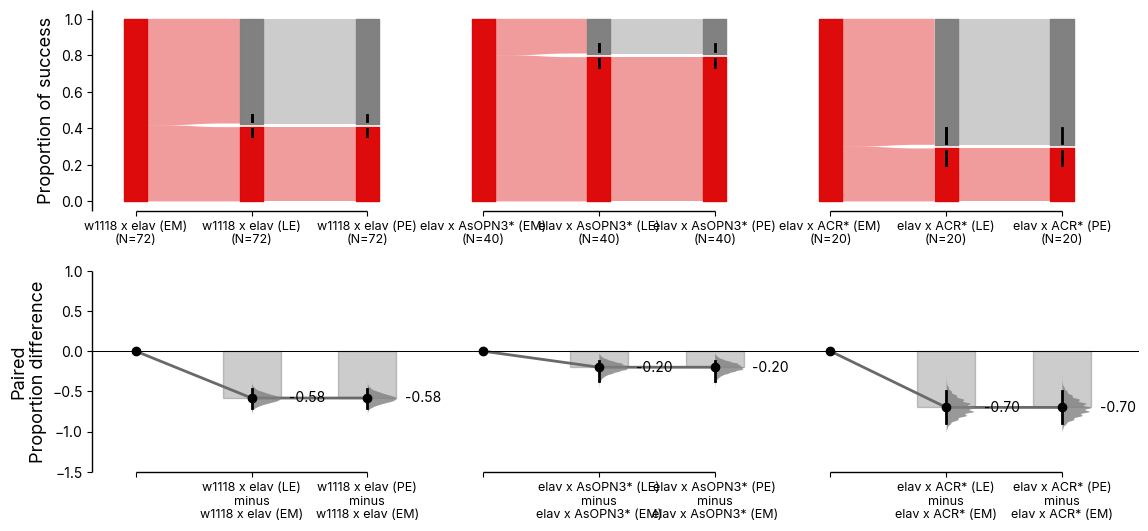

In [ ]:
multi_groups_baseline = dabest.load(dftotal, idx=(("w1118 x elav (EM)", "w1118 x elav (LE)", 'w1118 x elav (PE)' )
                                                  ,("elav x AsOPN3* (EM)", "elav x AsOPN3* (LE)", 'elav x AsOPN3* (PE)')
                                                  ,("elav x ACR* (EM)", "elav x ACR* (LE)", 'elav x ACR* (PE)')), x = "variable", y = "value",
                                        proportional=True, paired="baseline", id_col="ID")
fig = plt.figure(figsize=(8, 6))

color_wt = "#000000"
color_trans = "#DD0808"  
color_gray = "#808080"

common_style = {'fontsize_rawxlabel': 9, 'fontsize_rawylabel': 13, 'fontsize_contrastxlabel': 9,
                'fontsize_contrastylabel': 13, 'fontsize_delta2label': 12, 'contrast_marker_size': 6}

f = multi_groups_baseline.mean_diff.plot(custom_palette={0: "#808080", 1: color_trans}, 
    contrast_ylim = (-1.5, 1), **common_style);

# multi_groups_baseline.mean_diff.plot(title="Fecundity plots (n = " + str(repeats) + " replicates)",
#     prop_sample_counts=True, prop_sample_counts_kwargs={"color":"black"}, contrast_ylim = (-1.5, 1),  fontsize_rawxlabel=8, fontsize_rawylabel=10, fontsize_contrastxlabel=8, contrast_marker_size=4,
#                                     fontsize_contrastylabel=10, fontsize_delta2label=10);


mpl.rcParams['svg.fonttype'] = 'none' 
plt.show()
#f.savefig(openPath + "Fecundity_withATR.svg", bbox_inches = 'tight')